# 01 · Exploratory Data Analysis

**Dataset:** *Default of Credit Card Clients* (UCI ML Repository, id 350) — 30,000 credit-card
clients in Taiwan (Apr–Sep 2005). The task is to predict whether a client **defaults on
their payment next month** (`TARGET = 1`).

This notebook covers: dataset overview, the **data dictionary**, **class balance**,
**missing-value** analysis, univariate **distributions**, **bivariate** default-rate
analysis, the **correlation** structure, an explicit **target-leakage** check, and finally
writes a reproducible **stratified train/test split** to `data/processed/`.

> All paths come from `src.utils.config` — nothing is hardcoded. Re-run top-to-bottom with
> `make eda`.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

# Make the repo root importable regardless of the kernel's working directory.
_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.utils.logging import configure_logging

# Keep INFO logs (timestamps, absolute paths) out of the notebook outputs.
configure_logging("WARNING")

from src.data.dataset import (
    BILL_AMT_FEATURES,
    CATEGORICAL_FEATURES,
    DATA_DICTIONARY,
    NUMERIC_FEATURES,
    PAY_AMT_FEATURES,
    REPAYMENT_STATUS_FEATURES,
    TARGET_COLUMN,
    make_splits,
    save_splits,
)
from src.data.download import load_application_frame
from src.utils.config import get_settings
from src.viz.style import (
    DIVERGING_RAMP,
    PALETTE,
    apply_style,
    colors,
    compose,
    format_number,
    grid,
    label_bars,
    percent,
    thousands,
)

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()  # NyxAI Editorial v3: dark paper, cream ink, green as the only accent
pd.set_option("display.max_columns", 50)

settings = get_settings()
REPORTS = settings.reports_dir / "eda"
REPORTS.mkdir(parents=True, exist_ok=True)
RNG = settings.random_seed
SOURCE = "Source: Default of Credit Card Clients, UCI ML Repository, id 350"
print(f"Random seed: {RNG}")
print(f"Reports dir: {REPORTS.relative_to(settings.repo_root)}")

Random seed: 42
Reports dir: reports/eda


## 1 · Load the data

Downloads + checksum-verifies on first run, then reads the tidy CSV.

In [2]:
df = load_application_frame(settings)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 30,000 rows x 24 columns


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# Dtypes and a quick statistical summary.
display(df.dtypes.to_frame("dtype").T)
df.describe().T.round(2)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET
dtype,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.60,0.49,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.84,0.74,1.0,1.00,2.0,2.00,4.0
MARRIAGE,30000.0,1.56,0.52,1.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.27,1.13,-2.0,-1.00,0.0,0.00,8.0


## 2 · Data dictionary

What every column means (the basis for the docs/data card).

In [4]:
data_card = pd.DataFrame(
    [(c, DATA_DICTIONARY.get(c, "—"), str(df[c].dtype), df[c].nunique())
     for c in df.columns],
    columns=["feature", "description", "dtype", "n_unique"],
)
data_card

,feature,description,dtype,n_unique
0,LIMIT_BAL,"Amount of given credit (NT dollars), incl. ind...",int64,81
1,SEX,"Gender (1 = male, 2 = female)",int64,2
2,EDUCATION,"Education (1 = graduate school, 2 = university...",int64,4
3,MARRIAGE,"Marital status (1 = married, 2 = single, 3 = o...",int64,3
4,AGE,Age in years,int64,56
5,PAY_1,"Repayment status in month -1 (-1 = paid duly, ...",int64,11
6,PAY_2,Repayment status in month -2,int64,11
7,PAY_3,Repayment status in month -3,int64,11
8,PAY_4,Repayment status in month -4,int64,11
9,PAY_5,Repayment status in month -5,int64,10


## 3 · Target & class balance

The positive class (default) is the minority — this drives our choice of metrics
(ROC AUC / PR AUC over raw accuracy) and class-imbalance handling in modelling.

,count,proportion
No default (0),23364,0.7788
Default (1),6636,0.2212


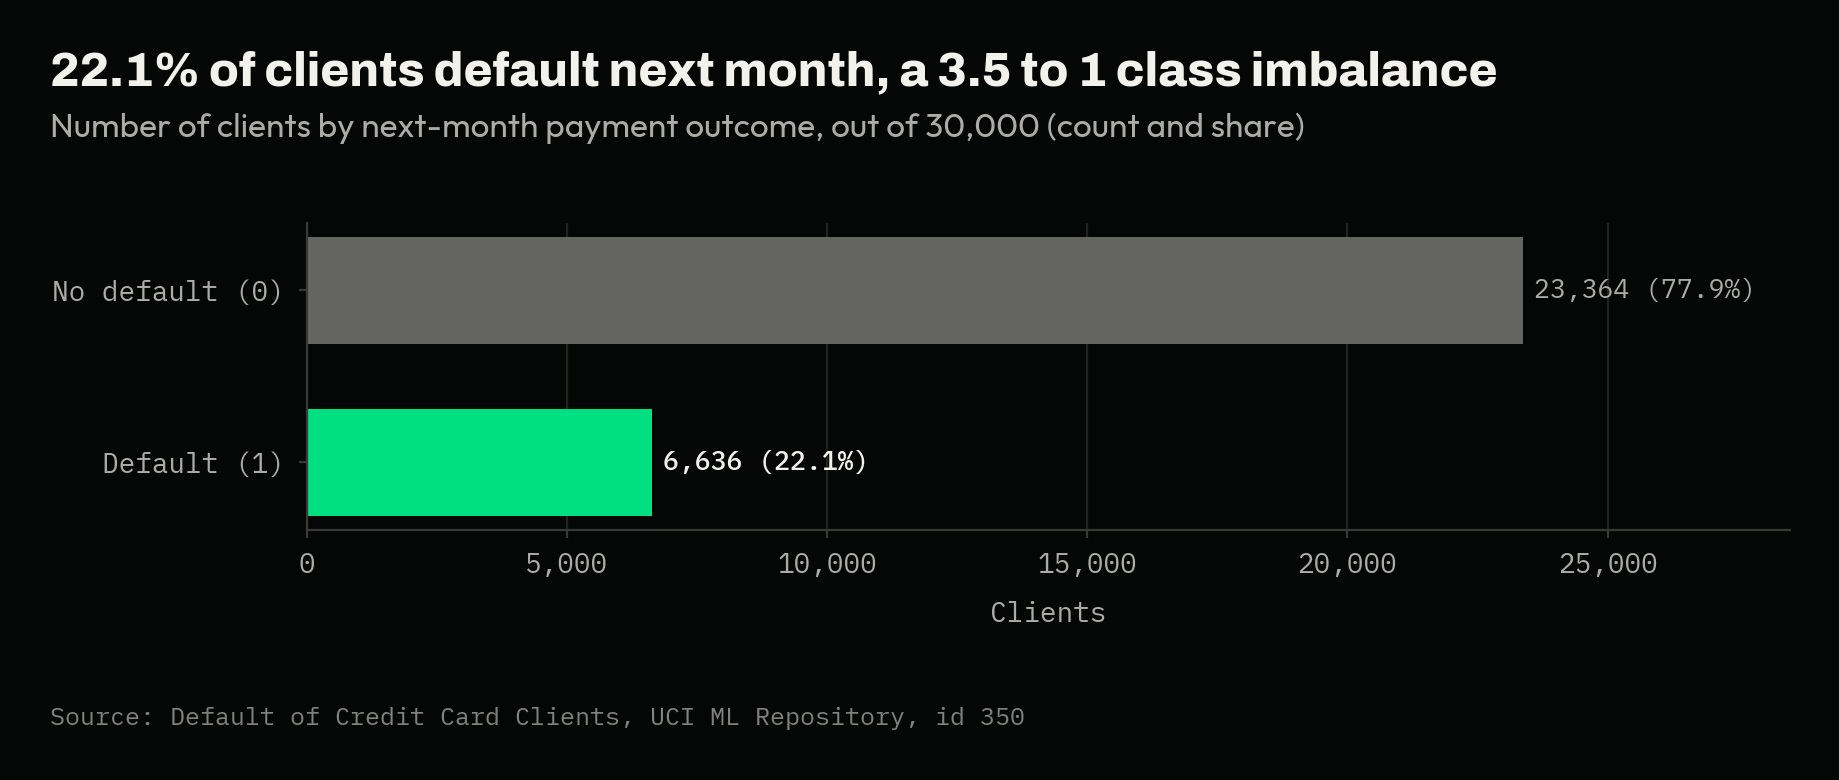

Imbalance ratio (majority:minority) = 3.52 : 1


In [5]:
counts = df[TARGET_COLUMN].value_counts().sort_index()
rates = df[TARGET_COLUMN].value_counts(normalize=True).sort_index()
balance = pd.DataFrame({"count": counts, "proportion": rates.round(4)})
balance.index = ["No default (0)", "Default (1)"]
display(balance)

imbalance = counts.max() / counts.min()
fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.barh(balance.index, balance["count"], height=0.62,
               color=colors(balance.index, "Default (1)"))
label_bars(ax, bars, [f"{v:,} ({r:.1%})" for v, r in zip(balance["count"], rates)], highlight={1})
ax.invert_yaxis()
ax.set_xlim(0, balance["count"].max() * 1.22)
ax.set_xlabel("Clients")
thousands(ax, "x")
grid(ax, "x")
compose(
    fig,
    f"{rates.iloc[1]:.1%} of clients default next month, a {imbalance:.1f} to 1 class imbalance",
    f"Number of clients by next-month payment outcome, out of {len(df):,} (count and share)",
    SOURCE,
)
fig.savefig(REPORTS / "class_balance.png")
plt.show()

print(f"Imbalance ratio (majority:minority) = {imbalance:.2f} : 1")

## 4 · Missing values & data quality

UCI ships this set fully populated, but we verify explicitly and also probe for
*implicit* missingness — sentinel codes and undocumented categories.

In [6]:
missing = df.isna().sum()
print("Columns with NaN:", int((missing > 0).sum()))
display(missing[missing > 0])

# Implicit issues: documented categorical domains.
print("EDUCATION codes:", sorted(df['EDUCATION'].unique()))   # 1..4 after cleaning
print("MARRIAGE codes :", sorted(df['MARRIAGE'].unique()))     # 1..3 after cleaning
print("SEX codes      :", sorted(df['SEX'].unique()))          # 1,2

# Duplicate rows?
print("Exact duplicate rows:", int(df.duplicated().sum()))

Columns with NaN: 0


Series([], dtype: int64)

EDUCATION codes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE codes : [np.int64(1), np.int64(2), np.int64(3)]
SEX codes      : [np.int64(1), np.int64(2)]
Exact duplicate rows: 35


## 5 · Numeric distributions

`LIMIT_BAL` and the monetary `BILL_AMT*` / `PAY_AMT*` features are heavily right-skewed —
a signal that tree models (robust to monotonic transforms) will likely beat linear ones,
and that we should consider log-scaling for the linear baseline.

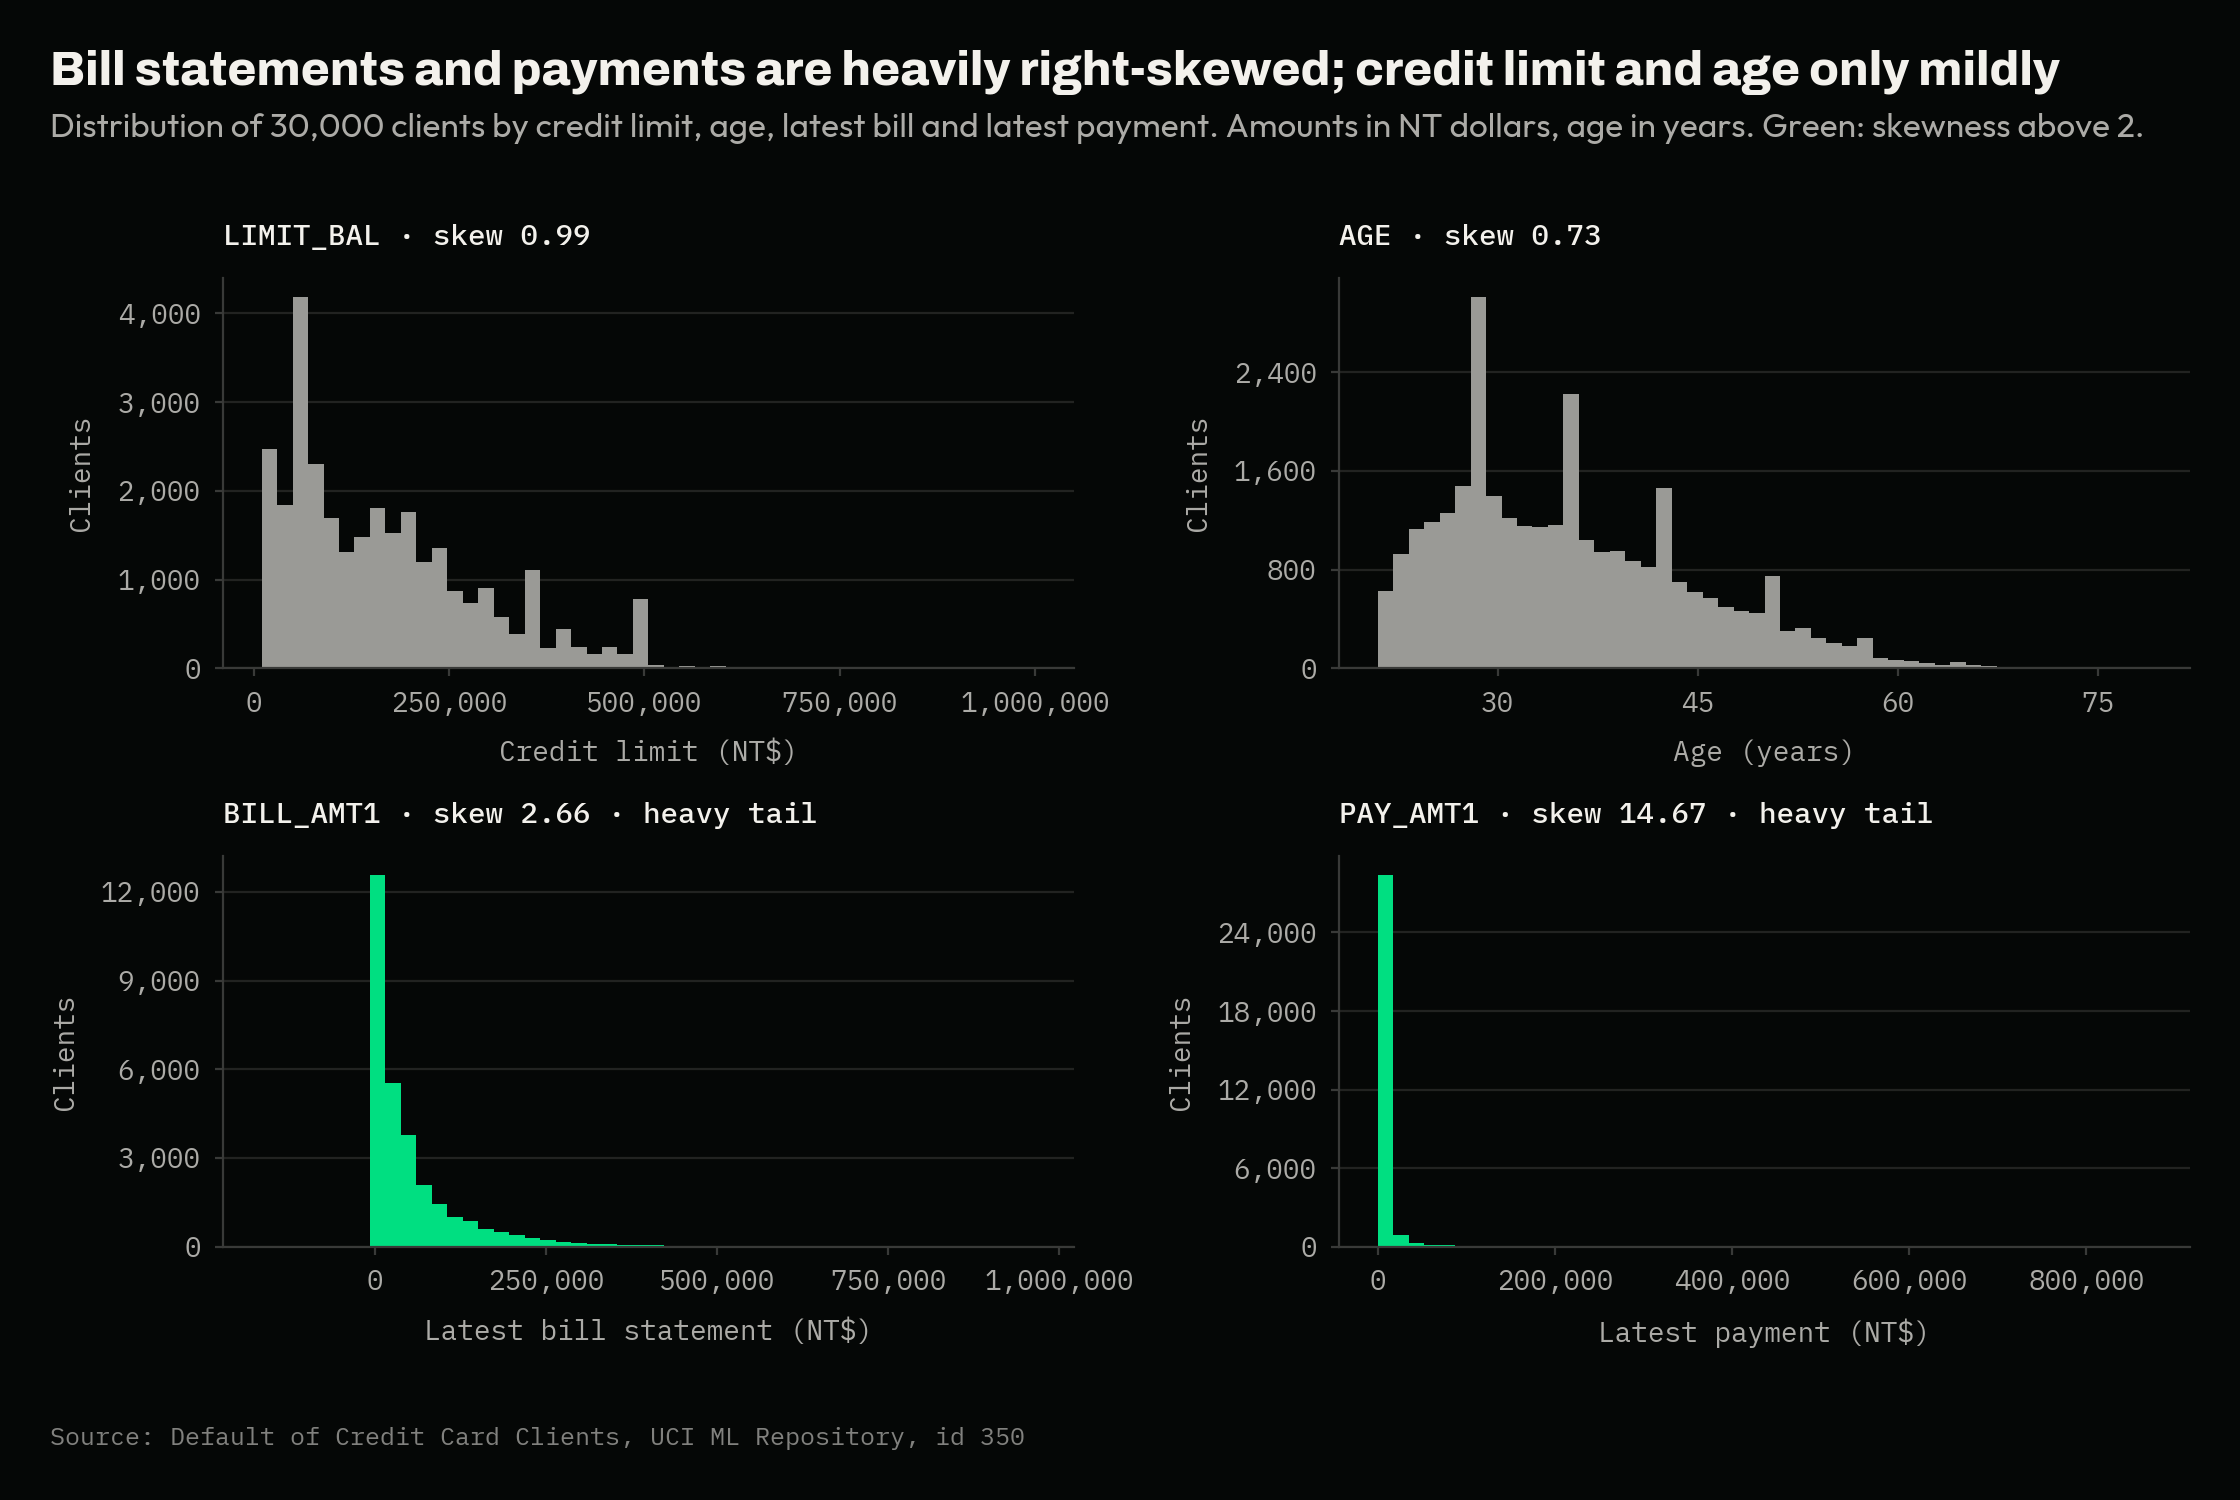

In [7]:
skew_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]
units = {
    "LIMIT_BAL": "Credit limit (NT$)",
    "AGE": "Age (years)",
    "BILL_AMT1": "Latest bill statement (NT$)",
    "PAY_AMT1": "Latest payment (NT$)",
}
fig, axes = plt.subplots(2, 2, figsize=(11, 7.4))
for ax, col in zip(axes.ravel(), skew_cols):
    skew = df[col].skew()
    heavy = skew > 2
    ax.hist(df[col], bins=50, color=PALETTE["green"] if heavy else PALETTE["neutral_light"])
    ax.set_title(f"{col} · skew {skew:.2f}" + (" · heavy tail" if heavy else ""))
    ax.set_xlabel(units[col])
    ax.set_ylabel("Clients")
    thousands(ax, "x", nbins=5)
    thousands(ax, "y", nbins=5)
    grid(ax, "y")
compose(
    fig,
    "Bill statements and payments are heavily right-skewed; credit limit and age only mildly",
    f"Distribution of {len(df):,} clients by credit limit, age, latest bill and latest payment. "
    "Amounts in NT dollars, age in years. Green: skewness above 2.",
    SOURCE,
)
fig.savefig(REPORTS / "numeric_distributions.png")
plt.show()

,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


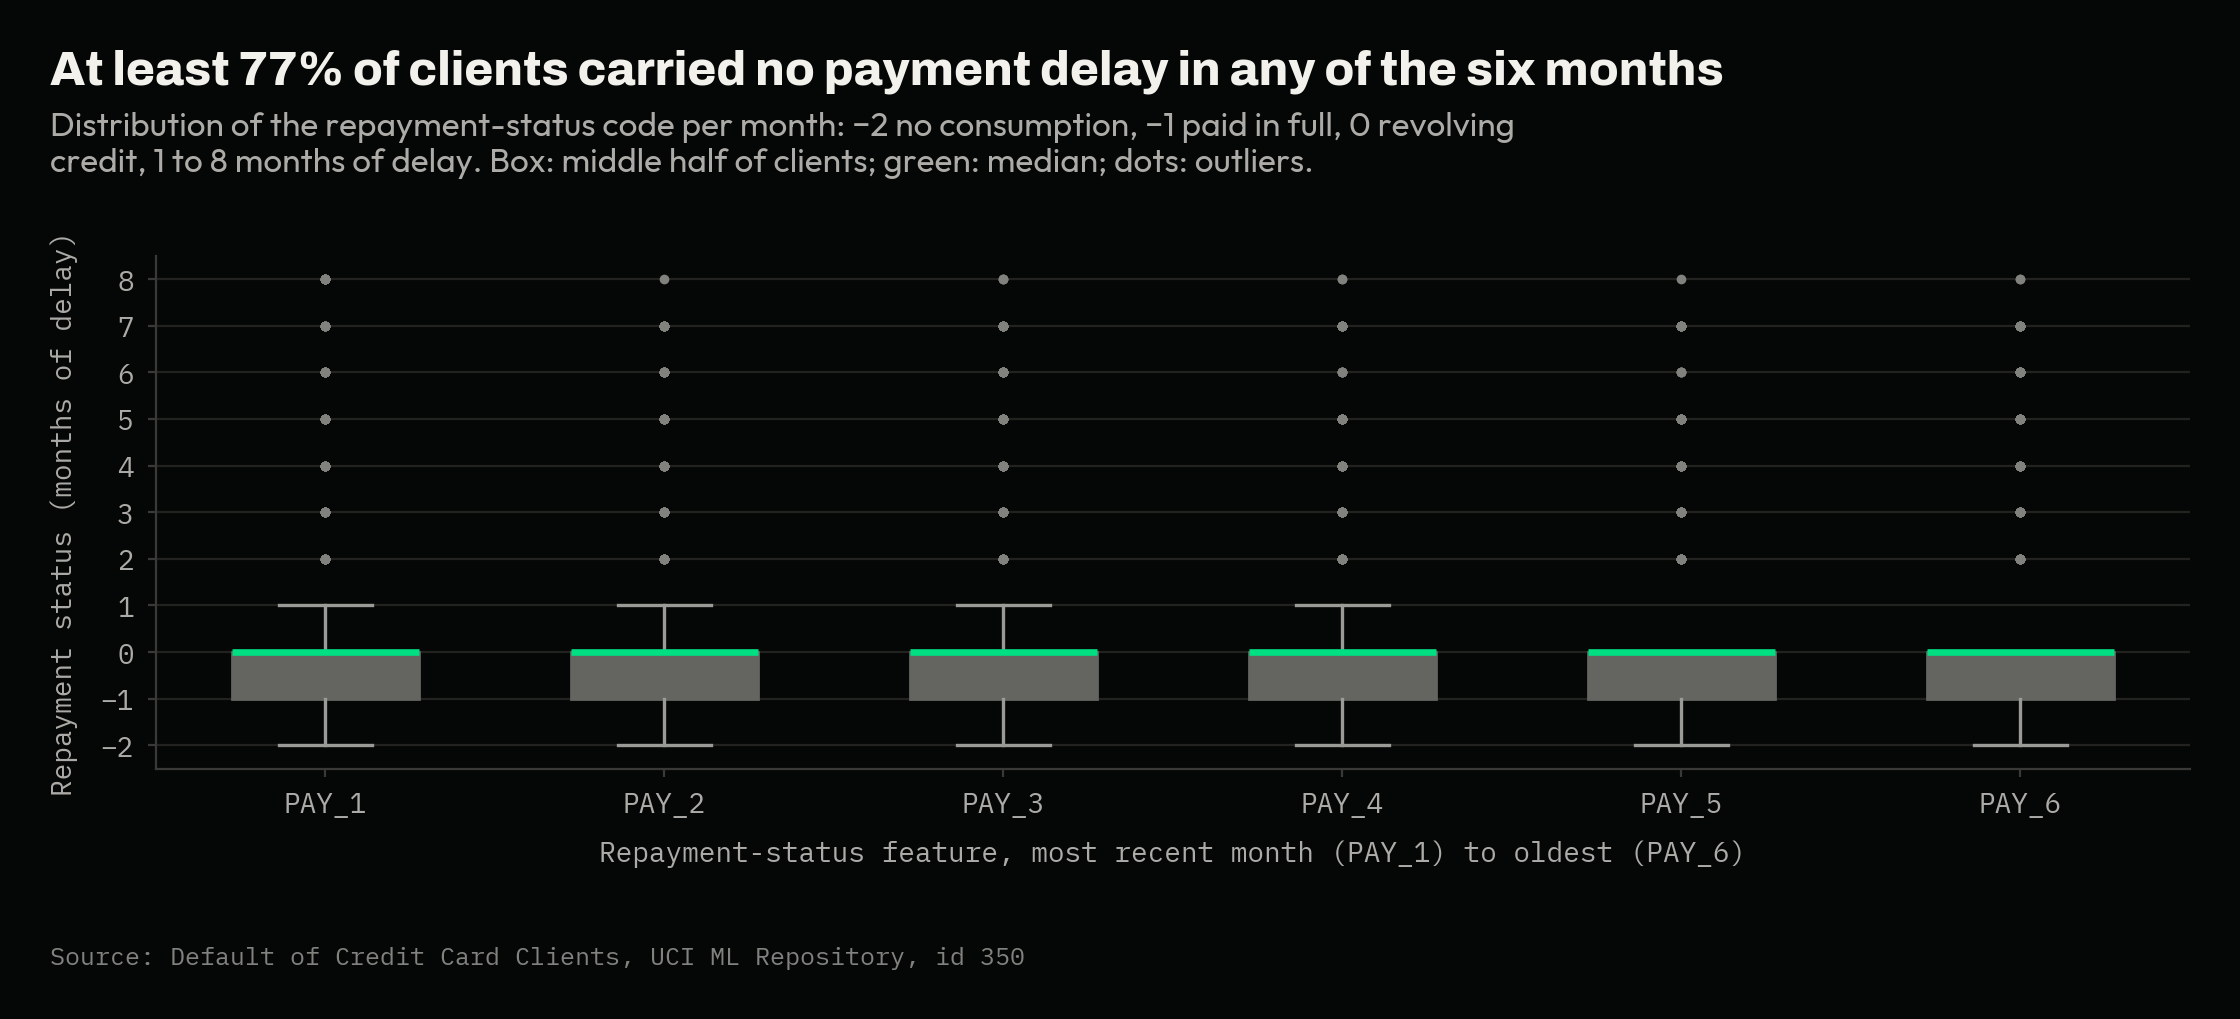

In [8]:
# Repayment-status features are ordinal (-2..8): months of payment delay.
pay_dist = df[list(REPAYMENT_STATUS_FEATURES)].apply(pd.Series.value_counts).fillna(0).astype(int)
display(pay_dist)
no_delay = (df[list(REPAYMENT_STATUS_FEATURES)] <= 0).mean()
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(
    [df[c] for c in REPAYMENT_STATUS_FEATURES],
    tick_labels=list(REPAYMENT_STATUS_FEATURES),
    widths=0.55,
    patch_artist=True,
    boxprops={"facecolor": PALETTE["neutral"], "edgecolor": PALETTE["neutral"]},
    whiskerprops={"color": PALETTE["neutral_light"], "linewidth": 1.2},
    capprops={"color": PALETTE["neutral_light"], "linewidth": 1.2},
    medianprops={"color": PALETTE["green"], "linewidth": 2.4},
    flierprops={"marker": "o", "markersize": 3.5, "markerfacecolor": PALETTE["faint"],
                "markeredgecolor": "none"},
)
ax.set_yticks(range(-2, 9), [format_number(v) for v in range(-2, 9)])
ax.set_xlabel("Repayment-status feature, most recent month (PAY_1) to oldest (PAY_6)")
ax.set_ylabel("Repayment status (months of delay)")
grid(ax, "y")
compose(
    fig,
    f"At least {no_delay.min():.0%} of clients carried no payment delay in any of the six months",
    "Distribution of the repayment-status code per month: −2 no consumption, −1 paid in full, "
    "0 revolving credit, 1 to 8 months of delay. Box: middle half of clients; green: median; "
    "dots: outliers.",
    SOURCE,
)
fig.savefig(REPORTS / "repayment_status.png")
plt.show()

## 6 · Bivariate analysis — default rate by segment

How the default rate moves across categorical segments and recent repayment status.
`PAY_1` (most recent month's delay) shows a very strong, monotonic relationship with
default — our strongest single predictor.

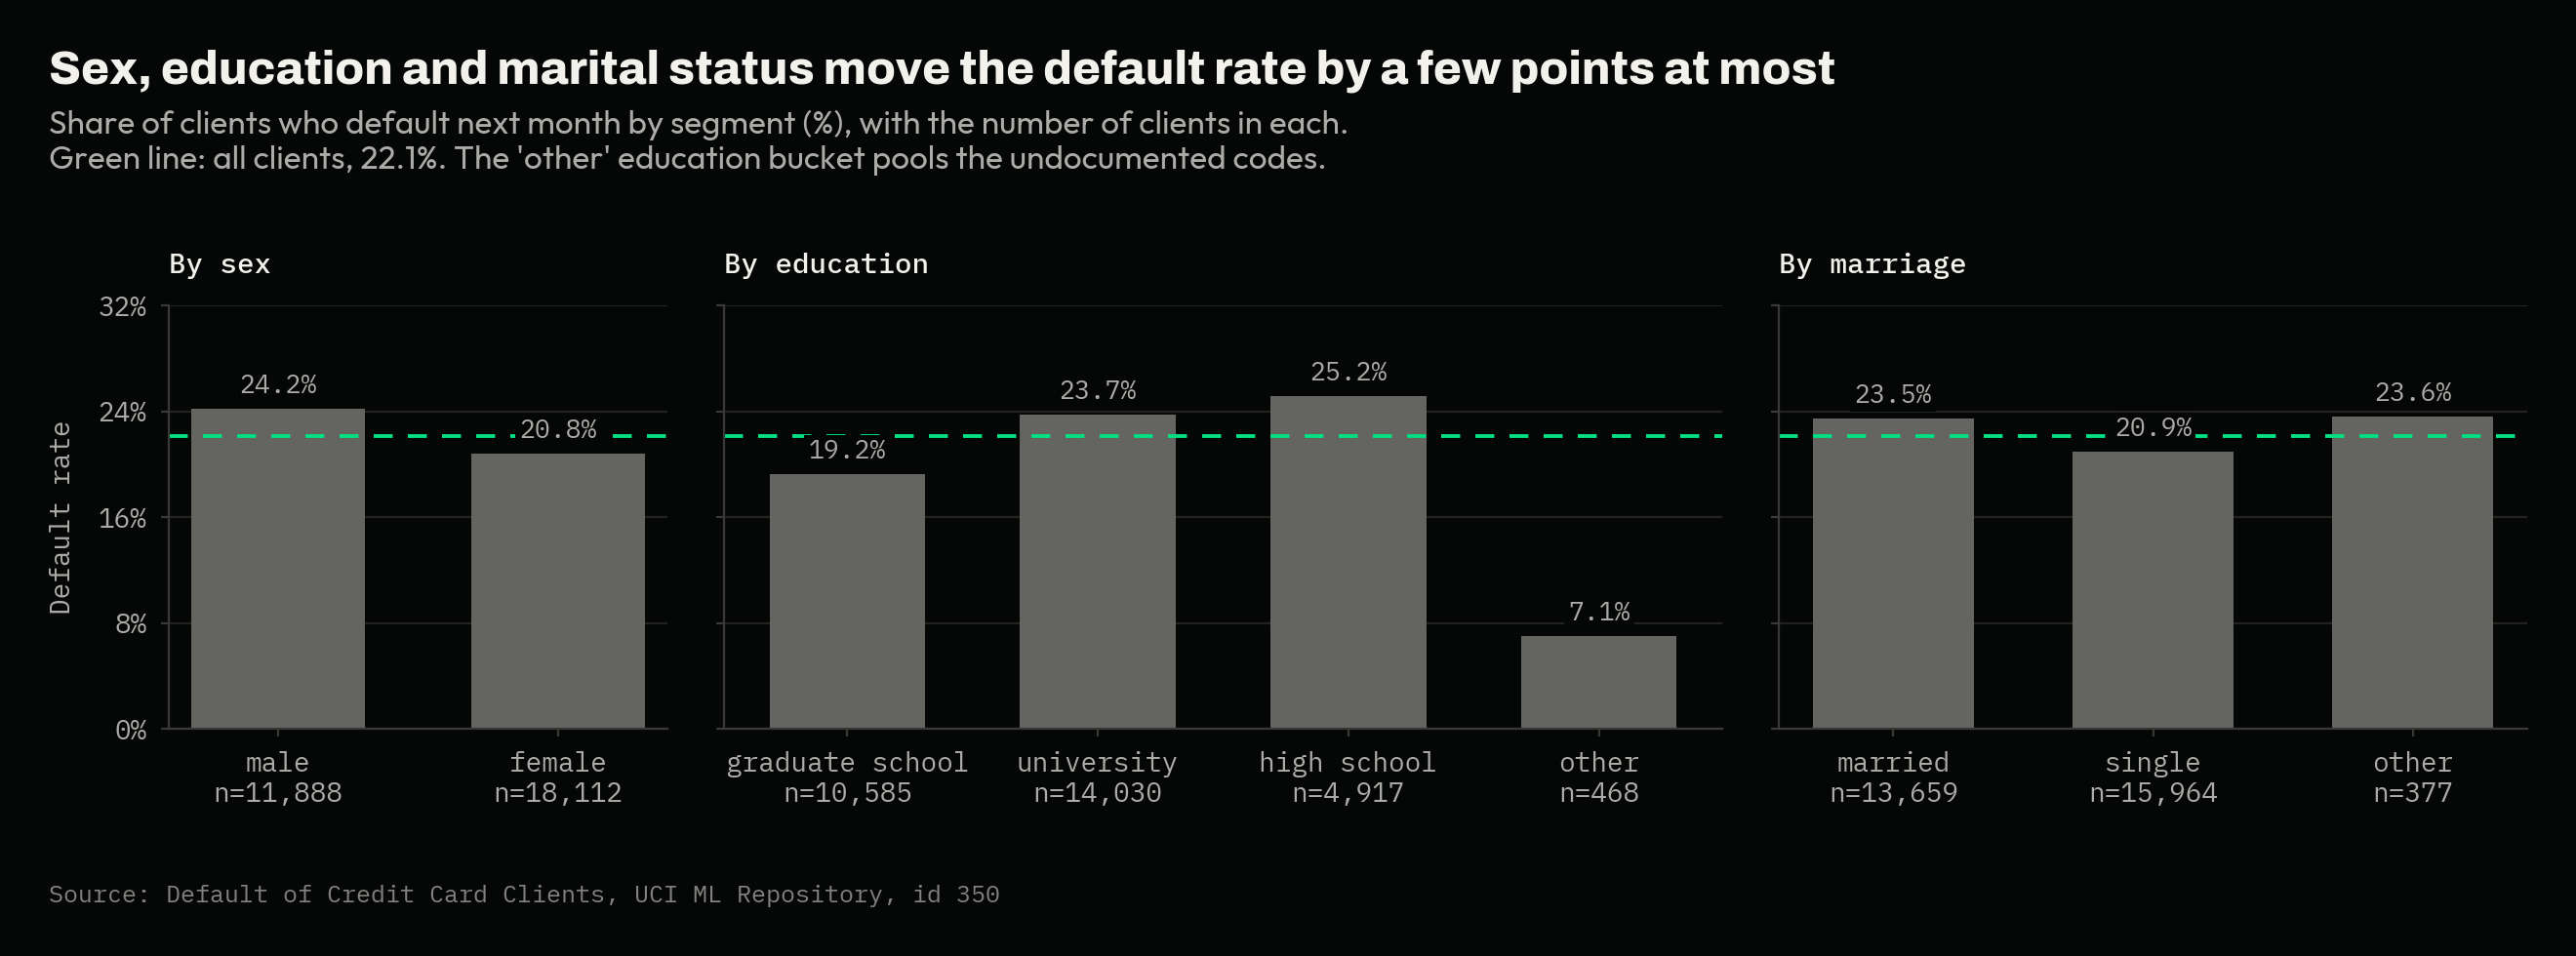

In [9]:
CODE_LABELS = {
    "SEX": {1: "male", 2: "female"},
    "EDUCATION": {1: "graduate school", 2: "university", 3: "high school", 4: "other"},
    "MARRIAGE": {1: "married", 2: "single", 3: "other"},
}
overall = df[TARGET_COLUMN].mean()
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), sharey=True,
                         gridspec_kw={"width_ratios": [2, 4, 3]})  # one unit per bar
for ax, col in zip(axes, CATEGORICAL_FEATURES):
    seg = df.groupby(col)[TARGET_COLUMN].agg(["mean", "count"]).sort_index()
    ticks = [f"{CODE_LABELS[col].get(code, code)}\nn={n:,}"
             for code, n in zip(seg.index, seg["count"])]
    bars = ax.bar(ticks, seg["mean"], width=0.62, color=PALETTE["neutral"])
    ax.axhline(overall, color=PALETTE["green"], linewidth=1.4, linestyle=(0, (5, 4)))
    label_bars(ax, bars, [f"{r:.1%}" for r in seg["mean"]], mask=True)
    ax.set_title(f"By {col.lower()}")
    ax.set_ylim(0, 0.32)
    percent(ax, "y", nbins=4)
    grid(ax, "y")
axes[0].set_ylabel("Default rate")
compose(
    fig,
    "Sex, education and marital status move the default rate by a few points at most",
    "Share of clients who default next month by segment (%), with the number of clients in each. "
    f"Green line: all clients, {overall:.1%}. The 'other' education bucket pools the undocumented codes.",
    SOURCE,
)
fig.savefig(REPORTS / "default_rate_categorical.png")
plt.show()

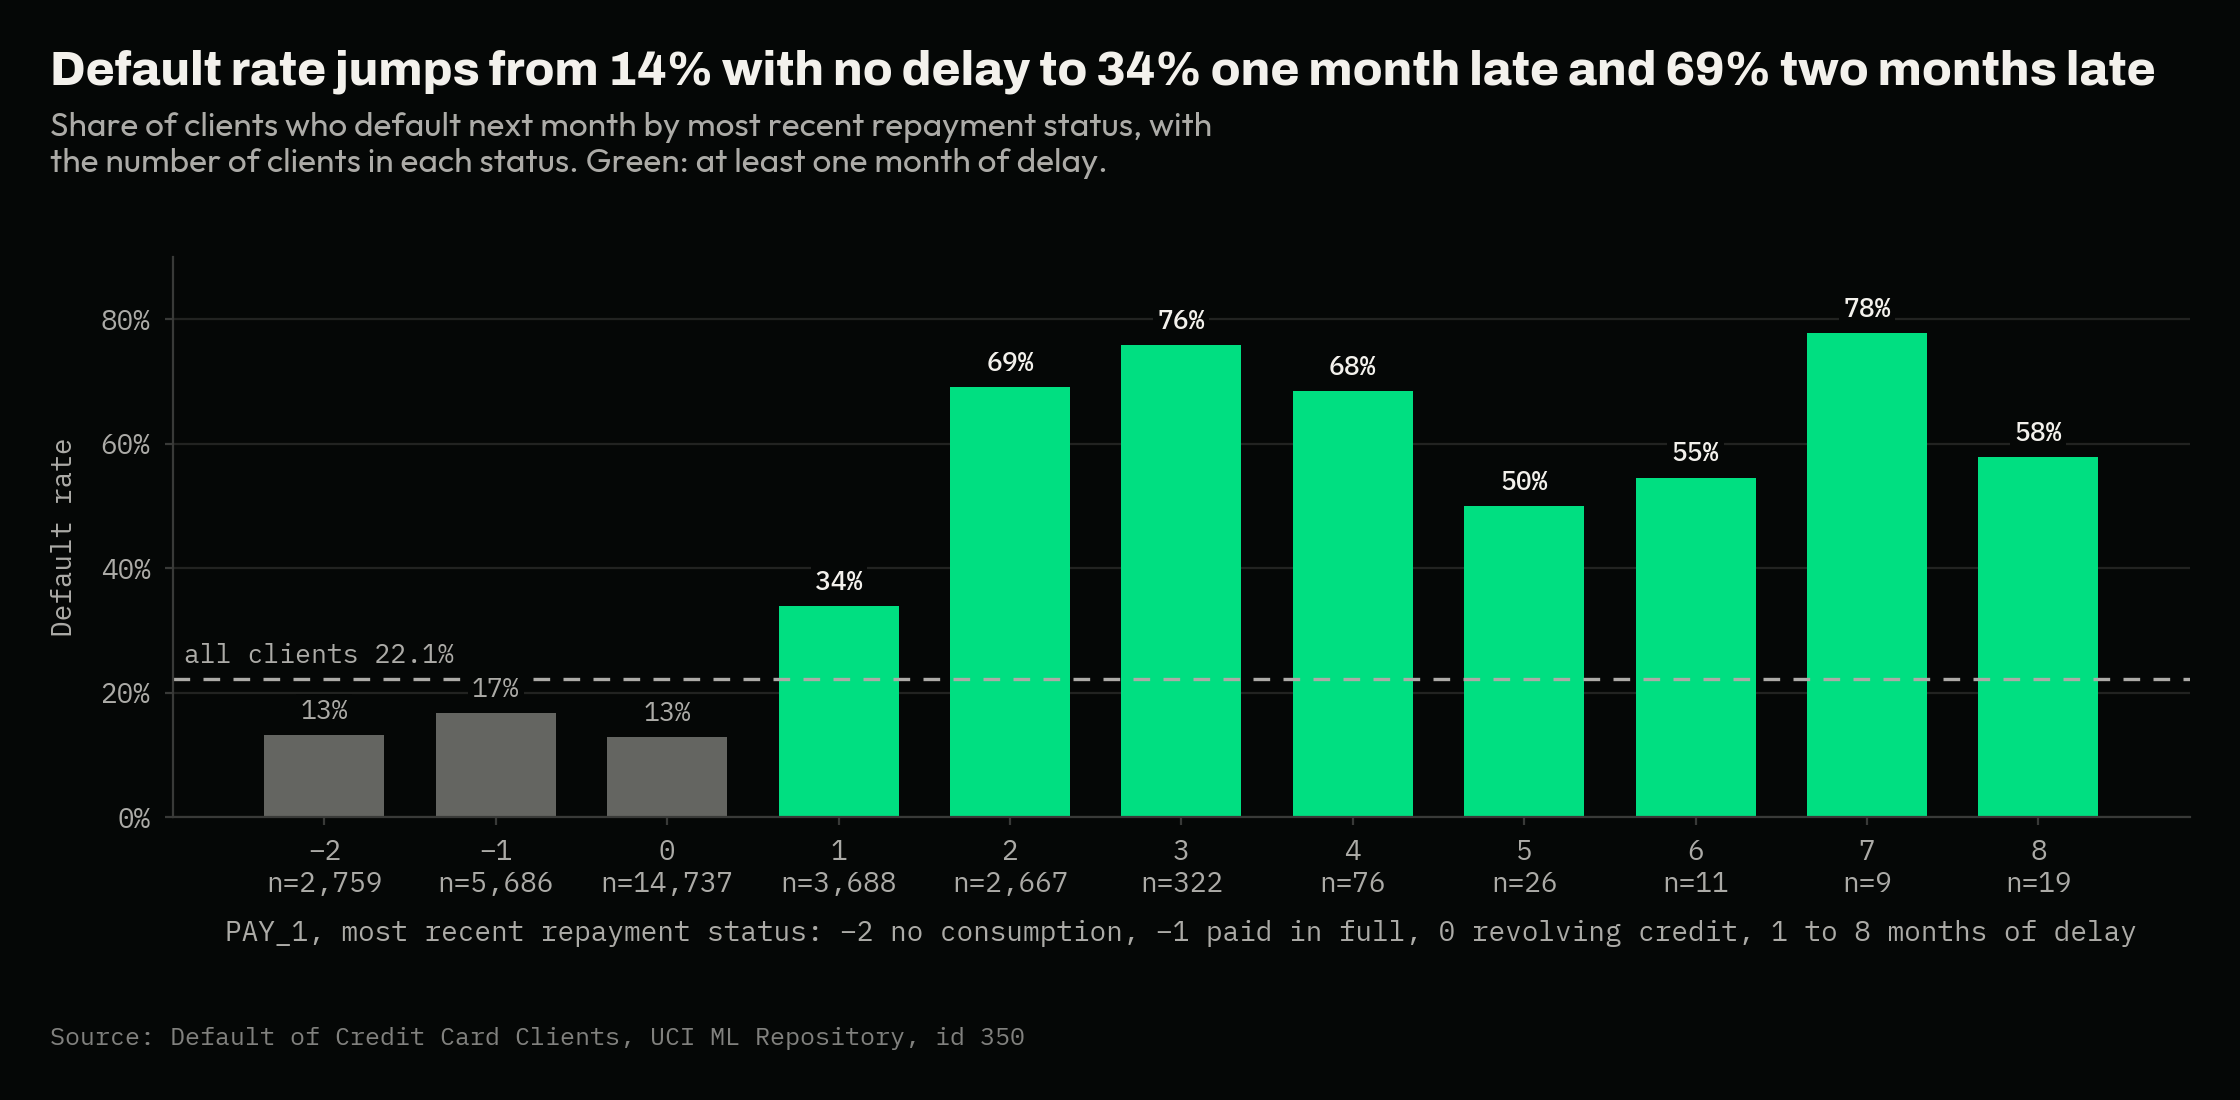

,mean,count
PAY_1,,
-2,0.132,2759
-1,0.168,5686
0,0.128,14737
1,0.339,3688
2,0.691,2667
3,0.758,322
4,0.684,76
5,0.500,26
6,0.545,11


In [10]:
rate_pay = df.groupby("PAY_1")[TARGET_COLUMN].agg(["mean", "count"])
by_status = rate_pay["mean"]
delayed = [code for code in rate_pay.index if code >= 1]
no_delay_rate = df.loc[df["PAY_1"] <= 0, TARGET_COLUMN].mean()

fig, ax = plt.subplots(figsize=(11, 5.4))
ticks = [f"{format_number(code)}\nn={n:,}" for code, n in zip(rate_pay.index, rate_pay["count"])]
bars = ax.bar(ticks, by_status, width=0.7, color=colors(rate_pay.index, delayed))
ax.axhline(overall, color=PALETTE["muted"], linewidth=1.2, linestyle=(0, (5, 4)))
label_bars(ax, bars, [f"{r:.0%}" for r in by_status], mask=True,
           highlight={i for i, code in enumerate(rate_pay.index) if code >= 1})
ax.annotate(f"all clients {overall:.1%}", xy=(0, overall), xycoords=("axes fraction", "data"),
            xytext=(4, 4), textcoords="offset points", ha="left", va="bottom",
            color=PALETTE["muted"], fontsize=9.5)
ax.set_ylim(0, 0.9)
ax.set_xlabel("PAY_1, most recent repayment status: −2 no consumption, −1 paid in full, "
              "0 revolving credit, 1 to 8 months of delay")
ax.set_ylabel("Default rate")
percent(ax, "y", nbins=5)
grid(ax, "y")
compose(
    fig,
    f"Default rate jumps from {no_delay_rate:.0%} with no delay to {by_status[1]:.0%} one month "
    f"late and {by_status[2]:.0%} two months late",
    "Share of clients who default next month by most recent repayment status, with the number "
    "of clients in each status. Green: at least one month of delay.",
    SOURCE,
)
fig.savefig(REPORTS / "default_rate_pay1.png")
plt.show()
display(rate_pay.round(3))

## 7 · Correlation structure

The `BILL_AMT*` features are highly collinear (consecutive monthly balances).

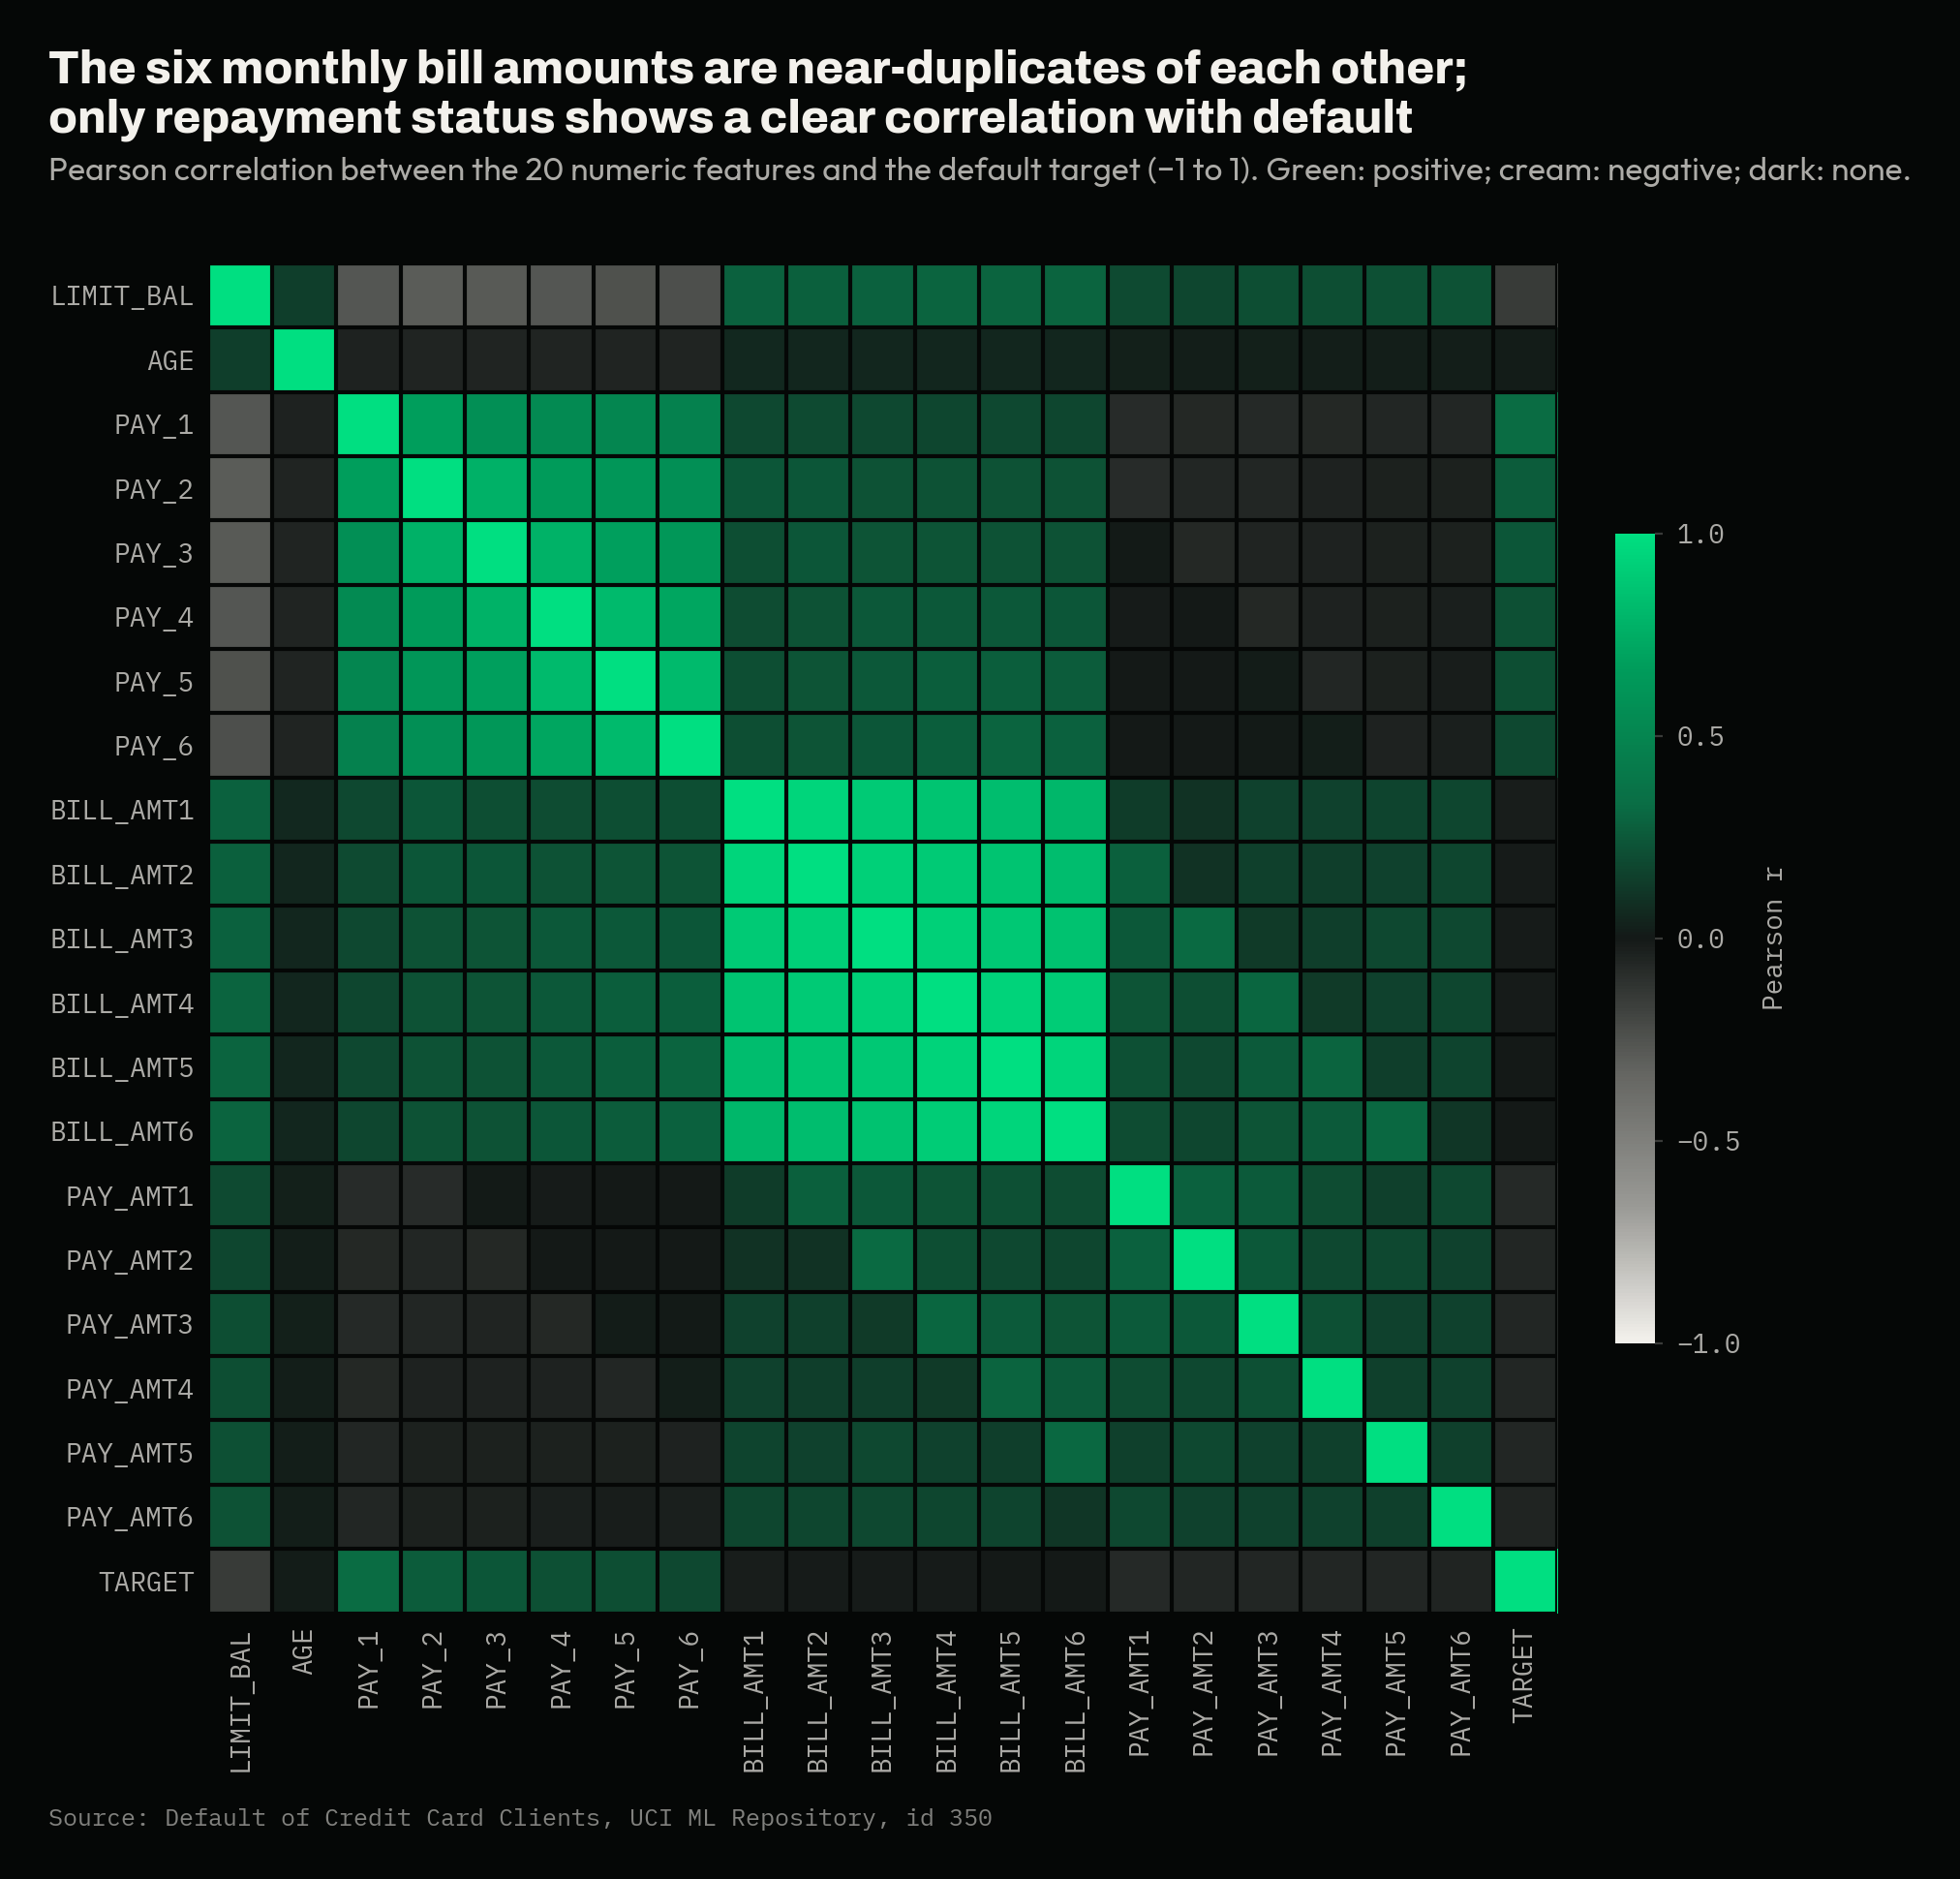

In [11]:
corr = df[list(NUMERIC_FEATURES) + [TARGET_COLUMN]].corr()
n = len(corr)
fig, ax = plt.subplots(figsize=(11, 9.6))
im = ax.imshow(corr.to_numpy(), cmap=DIVERGING_RAMP, vmin=-1, vmax=1)
ax.set_xticks(range(n), corr.columns, rotation=90)
ax.set_yticks(range(n), corr.index)
# Hairlines in the paper colour separate the cells; they must sit above the image.
ax.set_xticks(np.arange(-0.5, n), minor=True)
ax.set_yticks(np.arange(-0.5, n), minor=True)
ax.grid(which="minor", color=PALETTE["paper"], linewidth=1.5)
ax.set_axisbelow(False)
ax.tick_params(which="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
levels = [-1, -0.5, 0, 0.5, 1]
cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.03, ticks=levels)
cbar.ax.set_yticklabels([format_number(v, decimals=1) for v in levels])
cbar.outline.set_visible(False)
cbar.set_label("Pearson r")
compose(
    fig,
    "The six monthly bill amounts are near-duplicates of each other; only repayment status "
    "shows a clear correlation with default",
    f"Pearson correlation between the {n - 1} numeric features and the default target "
    "(−1 to 1). Green: positive; cream: negative; dark: none.",
    SOURCE,
)
fig.savefig(REPORTS / "correlation_heatmap.png")
plt.show()

In [12]:
target_corr = corr[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=np.abs, ascending=False)
print("Top correlations with TARGET:")
display(target_corr.head(10).to_frame("pearson_r").round(3))

Top correlations with TARGET:


,pearson_r
PAY_1,0.325
PAY_2,0.264
PAY_3,0.235
PAY_4,0.217
PAY_5,0.204
PAY_6,0.187
LIMIT_BAL,-0.154
PAY_AMT1,-0.073
PAY_AMT2,-0.059
PAY_AMT4,-0.057


## 8 · Target-leakage check

Leakage would mean a feature that encodes the outcome itself (information unavailable at
scoring time). We check three things:

1. **No feature is a perfect/near-perfect predictor.** The strongest correlation with the
   target is `PAY_1` (~0.32) — strong but far from leakage; it is a *legitimate* historical
   signal (last month's payment delay), known **before** the prediction month.
2. **All features are pre-decision.** Every `PAY_*`, `BILL_AMT*`, `PAY_AMT*` is from months
   -1 to -6 relative to the predicted month, so none can leak the future label.
3. **No duplicate of the target** under another name / no constant-vs-target columns.

In [13]:
max_abs_corr = target_corr.abs().max()
strongest = target_corr.abs().idxmax()
assert max_abs_corr < 0.95, "Potential leakage: a feature is near-perfectly correlated!"
print(f"Strongest |corr| with TARGET: {strongest} = {target_corr[strongest]:.3f}  -> OK (< 0.95)")

# Single-feature AUC sweep: any feature alone achieving AUC>~0.9 would be suspicious.
from sklearn.metrics import roc_auc_score
single = {}
for col in NUMERIC_FEATURES:
    try:
        single[col] = roc_auc_score(df[TARGET_COLUMN], df[col])
    except ValueError:
        single[col] = np.nan
single_auc = pd.Series(single).apply(lambda a: max(a, 1 - a)).sort_values(ascending=False)
print("\nTop single-feature AUCs (any > 0.90 would flag leakage):")
display(single_auc.head(8).to_frame("auc").round(3))
assert single_auc.max() < 0.90, "Potential leakage: a single feature is too predictive!"
print("\n✅ No target leakage detected.")

Strongest |corr| with TARGET: PAY_1 = 0.325  -> OK (< 0.95)



Top single-feature AUCs (any > 0.90 would flag leakage):


,auc
PAY_1,0.690
PAY_2,0.639
PAY_3,0.624
LIMIT_BAL,0.618
PAY_AMT1,0.611
PAY_4,0.610
PAY_AMT2,0.605
PAY_5,0.600



✅ No target leakage detected.


## 9 · Feature-engineering preview

A glimpse of the financial ratios Phase 2 will formalize — credit utilization and a
payment-to-bill ratio already separate the classes.

In [14]:
preview = df.copy()
preview["utilization_1"] = (preview["BILL_AMT1"] / preview["LIMIT_BAL"]).clip(-1, 5)
preview["pay_to_bill_1"] = (preview["PAY_AMT1"] / preview["BILL_AMT1"].replace(0, np.nan)).clip(0, 5)
display(preview.groupby(TARGET_COLUMN)[["utilization_1", "pay_to_bill_1"]].median().round(3))

,utilization_1,pay_to_bill_1
TARGET,,
0,0.267,0.063
1,0.493,0.049


## 10 · Reproducible train/test split

A single **stratified 80/20 split** (seeded from config) written to `data/processed/`.
All downstream phases load these exact partitions, so results are reproducible and the
test set is never touched during training.

In [15]:
train_df, test_df = make_splits(df, test_size=0.2, seed=RNG)
paths = save_splits(train_df, test_df, settings)

summary = pd.DataFrame({
    "rows": [len(train_df), len(test_df)],
    "default_rate": [train_df[TARGET_COLUMN].mean(), test_df[TARGET_COLUMN].mean()],
}, index=["train", "test"]).round(4)
display(summary)
print("Written:")
for name, p in paths.items():
    print(f"  {name}: {p.relative_to(settings.repo_root)}")

,rows,default_rate
train,24000,0.2212
test,6000,0.2212


Written:
  train: data/processed/train.parquet
  test: data/processed/test.parquet


## Key findings

- **30,000 clients, 23 features, no missing values.** Undocumented `EDUCATION`/`MARRIAGE`
  codes folded into an `other` bucket during ingestion.
- **Imbalanced target (~22% default, ~3.5:1).** Use ROC AUC / PR AUC, Gini, KS — not accuracy.
- **Strongest signal is recent repayment status (`PAY_1`).** Monotonic with default; a
  legitimate pre-decision feature, not leakage.
- **Heavy right-skew** in monetary features and **strong collinearity** among `BILL_AMT*` →
  favors tree-based models; financial **ratios** (utilization, payment coverage) look
  promising and will be engineered in Phase 2.
- **No target leakage**: max single-feature AUC < 0.90, max |corr| < 0.95, all features pre-decision.
- Stratified 80/20 split persisted to `data/processed/{train,test}.parquet`.